# HW4: Trees, Ensembles, and Naive Bayes

**Course**: DS4400  
**Student**: `BingXian Xie`


In [13]:
# Section 0: Imports and global config

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

np.random.seed(4400)
RANDOM_STATE = 4400
TEST_SIZE = 0.25

plt.style.use("seaborn-v0_8-whitegrid")

In [14]:
# Section 1: Shared utilities

def binary_metrics(y_true, y_pred, y_score=None):
    out = {
        "error": 1.0 - accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        out["auc"] = roc_auc_score(y_true, y_score)
    return out


def eval_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        yscore_train = model.predict_proba(X_train)[:, 1]
        yscore_test = model.predict_proba(X_test)[:, 1]
    else:
        yscore_train = None
        yscore_test = None

    train_m = binary_metrics(y_train, yhat_train, yscore_train)
    test_m = binary_metrics(y_test, yhat_test, yscore_test)
    return train_m, test_m


def metrics_to_df(results_dict):
    rows = []
    for model_name, val in results_dict.items():
        rows.append({"model": model_name, "split": "train", **val["train"]})
        rows.append({"model": model_name, "split": "test", **val["test"]})
    return pd.DataFrame(rows)

In [15]:
# Section 2: Load SPAMBASE data

NAMES_PATH = "spambase/spambase.names"
DATA_PATH = "spambase/spambase.data"

with open(NAMES_PATH, "r") as f:
    names_lines = f.readlines()

feature_names = []
for line in names_lines:
    line = line.strip()
    if ":" in line and "continuous" in line and (
        "word_freq_" in line
        or "char_freq_" in line
        or "capital_run_length_" in line
    ):
        feature_names.append(line.split(":")[0].strip())

spam_df = pd.read_csv(DATA_PATH, header=None)
X_spam = spam_df.iloc[:, :-1].values
y_spam = spam_df.iloc[:, -1].astype(int).values

if len(feature_names) != X_spam.shape[1]:
    feature_names = [f"x{i}" for i in range(X_spam.shape[1])]

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam,
    y_spam,
    test_size=TEST_SIZE,
    stratify=y_spam,
    random_state=RANDOM_STATE,
)

print("SPAMBASE shapes")
print("Train:", X_train_spam.shape, "Test:", X_test_spam.shape)
print("Class balance train:", pd.Series(y_train_spam).value_counts().to_dict())
print("Class balance test:", pd.Series(y_test_spam).value_counts().to_dict())

SPAMBASE shapes
Train: (3450, 57) Test: (1151, 57)
Class balance train: {0: 2091, 1: 1359}
Class balance test: {0: 697, 1: 454}


In [16]:
# Problem 1.1 and 1.2: Decision Tree with entropy and gini

p1_results = {}

# 1.1 Information gain (entropy)
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=RANDOM_STATE,
)
tr_e, te_e = eval_model(dt_entropy, X_train_spam, X_test_spam, y_train_spam, y_test_spam)
p1_results["DT_entropy_unpruned"] = {"train": tr_e, "test": te_e}

# 1.2 Gini
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE,
)
tr_g, te_g = eval_model(dt_gini, X_train_spam, X_test_spam, y_train_spam, y_test_spam)
p1_results["DT_gini_unpruned"] = {"train": tr_g, "test": te_g}

p1_metrics_df = metrics_to_df(p1_results)
p1_metrics_df

,model,split,error,accuracy,precision,recall,f1,auc
0,DT_entropy_unpruned,train,0.000290,0.999710,1.000000,0.999264,0.999632,1.000000
1,DT_entropy_unpruned,test,0.084275,0.915725,0.888889,0.898678,0.893757,0.912754
2,DT_gini_unpruned,train,0.000290,0.999710,1.000000,0.999264,0.999632,1.000000
3,DT_gini_unpruned,test,0.086881,0.913119,0.891593,0.887665,0.889625,0.908682


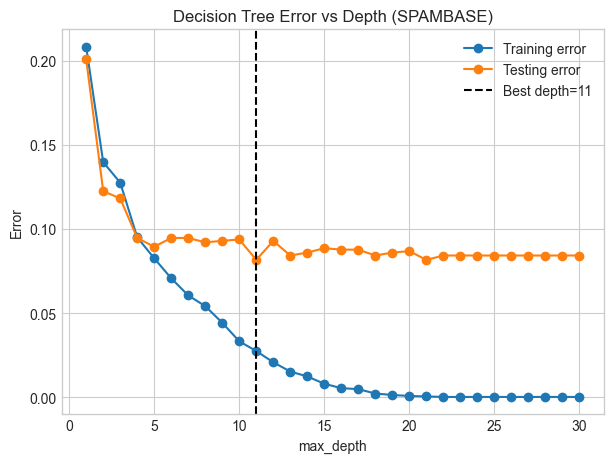

Recommended optimal depth (min test error): 11


,depth,train_error,test_error
0,1,0.208116,0.200695
1,2,0.139710,0.122502
2,3,0.127536,0.118158
3,4,0.095072,0.094700
4,5,0.082609,0.089487


In [17]:
# Problem 1.3: Max-depth pruning analysis

depths = list(range(1, 31))
train_errors = []
test_errors = []

for d in depths:
    dt_d = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=d,
        random_state=RANDOM_STATE,
    )
    dt_d.fit(X_train_spam, y_train_spam)
    train_errors.append(1.0 - accuracy_score(y_train_spam, dt_d.predict(X_train_spam)))
    test_errors.append(1.0 - accuracy_score(y_test_spam, dt_d.predict(X_test_spam)))

best_idx = int(np.argmin(test_errors))
best_depth = depths[best_idx]

plt.figure(figsize=(7, 5))
plt.plot(depths, train_errors, marker="o", label="Training error")
plt.plot(depths, test_errors, marker="o", label="Testing error")
plt.axvline(best_depth, linestyle="--", color="black", label=f"Best depth={best_depth}")
plt.xlabel("max_depth")
plt.ylabel("Error")
plt.title("Decision Tree Error vs Depth (SPAMBASE)")
plt.legend()
plt.show()

print("Recommended optimal depth (min test error):", best_depth)

p1_depth_df = pd.DataFrame({
    "depth": depths,
    "train_error": train_errors,
    "test_error": test_errors,
})
p1_depth_df.head()

### 1.1 Information Gain (Entropy)
Using an unpruned entropy tree, training performance is nearly perfect (train error `0.00029`, train F1 `0.9996`, train AUC `1.0000`), while test performance is lower (test error `0.0843`, test F1 `0.8938`, test AUC `0.9128`). This large train-test gap is a classic overfitting signal for an unpruned tree.

### 1.2 Gini Index
The gini tree also overfits with near-perfect training metrics, but on this split it is **slightly worse** than entropy on test metrics (test error `0.0869`, test F1 `0.8896`, test AUC `0.9087`). The difference is small, so both criteria are close; entropy is marginally better here.

### 1.3 Max-Depth Pruning
The depth sweep shows training error decreasing with depth, while testing error drops at first and then bottoms out before flattening/rising. The minimum testing error occurs at **depth 11** (`best_depth = 11`), so depth 11 is the recommended pruning level for the entropy tree on this data.

In [18]:
# Problem 2.1: Random Forest with T in {10, 50, 100, 500}

rf_T_values = [10, 50, 100, 500]
rf_results = {}

for T in rf_T_values:
    rf = RandomForestClassifier(
        n_estimators=T,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    tr, te = eval_model(rf, X_train_spam, X_test_spam, y_train_spam, y_test_spam)
    rf_results[f"RF_{T}"] = {"train": tr, "test": te}

rf_metrics_df = metrics_to_df(rf_results)
rf_metrics_df

,model,split,error,accuracy,precision,recall,f1,auc
0,RF_10,train,0.004348,0.995652,0.999257,0.989698,0.994455,0.999936
1,RF_10,test,0.052997,0.947003,0.953811,0.909692,0.931229,0.985593
2,RF_50,train,0.000580,0.999420,1.000000,0.998528,0.999264,0.999999
3,RF_50,test,0.046047,0.953953,0.952596,0.929515,0.940914,0.987116
4,RF_100,train,0.000290,0.999710,1.000000,0.999264,0.999632,0.999999
5,RF_100,test,0.043440,0.956560,0.963303,0.925110,0.943820,0.987682
6,RF_500,train,0.000290,0.999710,1.000000,0.999264,0.999632,1.000000
7,RF_500,test,0.043440,0.956560,0.963303,0.925110,0.943820,0.988386


RF vs Decision Tree comparison


,model,split,error,accuracy,precision,recall,f1,auc
0,DT_entropy_unpruned,train,0.000290,0.999710,1.000000,0.999264,0.999632,1.000000
1,DT_entropy_unpruned,test,0.084275,0.915725,0.888889,0.898678,0.893757,0.912754
2,RF_100,train,0.000290,0.999710,1.000000,0.999264,0.999632,0.999999
3,RF_100,test,0.043440,0.956560,0.963303,0.925110,0.943820,0.987682


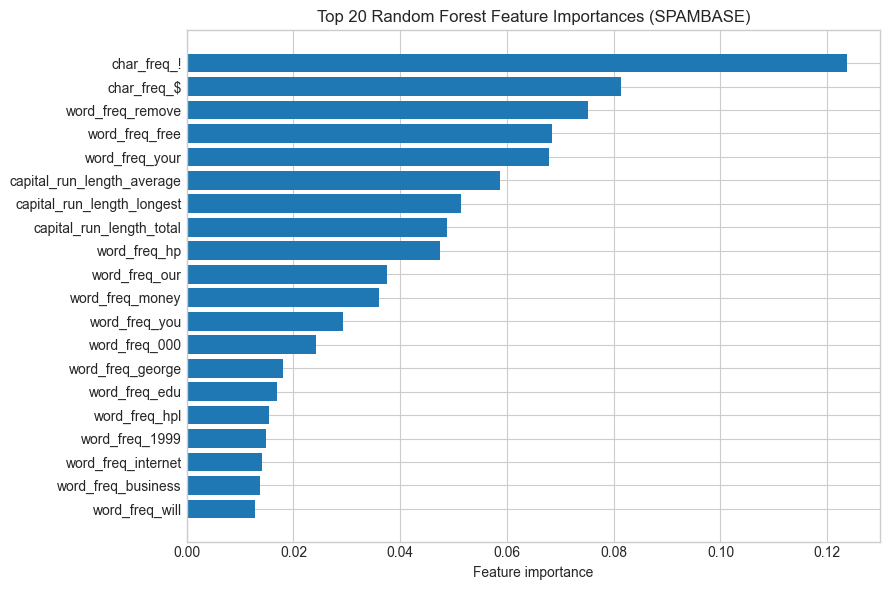

,feature,importance
0,char_freq_!,0.123709
1,char_freq_$,0.081444
2,word_freq_remove,0.075275
3,word_freq_free,0.068472
4,word_freq_your,0.067852
5,capital_run_length_average,0.058640
6,capital_run_length_longest,0.051364
7,capital_run_length_total,0.048851
8,word_freq_hp,0.047449
9,word_freq_our,0.037487


In [19]:
# Problem 2.2 and 2.3: Compare RF vs DT and plot feature importance

# Use RF with 100 trees for importance and comparison reference
rf100 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
tr_rf100, te_rf100 = eval_model(rf100, X_train_spam, X_test_spam, y_train_spam, y_test_spam)

# Compare against entropy DT from Problem 1
compare_rf_dt = pd.DataFrame([
    {"model": "DT_entropy_unpruned", "split": "train", **tr_e},
    {"model": "DT_entropy_unpruned", "split": "test", **te_e},
    {"model": "RF_100", "split": "train", **tr_rf100},
    {"model": "RF_100", "split": "test", **te_rf100},
])

print("RF vs Decision Tree comparison")
display(compare_rf_dt)

importances = rf100.feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

top_k = 20
plt.figure(figsize=(9, 6))
plt.barh(imp_df.loc[:top_k-1, "feature"][::-1], imp_df.loc[:top_k-1, "importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Top 20 Random Forest Feature Importances (SPAMBASE)")
plt.tight_layout()
plt.show()

imp_df.head(10)

### 2.1 Random Forest with Different Numbers of Trees
From `rf_metrics_df`, test metrics improve as `T` increases from 10 to 100 and then largely plateau: accuracy rises from `0.9470` (T=10) to `0.9566` (T=100/500), F1 rises from `0.9312` to `0.9438`, and AUC rises from `0.9856` to `0.9884`. This shows diminishing returns after about 100 trees.

### 2.2 Random Forest vs Decision Tree
Compared with the unpruned entropy tree (test accuracy `0.9157`, F1 `0.8938`, AUC `0.9128`), RF-100 is much stronger (test accuracy `0.9566`, F1 `0.9438`, AUC `0.9877`). The improvement aligns with ensemble variance reduction from bagging and feature randomness.

### 2.3 Feature Importance
The feature-importance plot highlights the top predictors used by the forest. The ranking emphasizes spam-indicative token and punctuation/capitalization behavior, which is consistent with known properties of the SPAMBASE feature design.

In [20]:
# Problem 3.1 and 3.2: AdaBoost metrics and comparison with RF

ada_T_values = [10, 50, 100, 500]
ada_results = {}

for T in ada_T_values:
    base_tree = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    ada = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=T,
        random_state=RANDOM_STATE,
    )
    tr, te = eval_model(ada, X_train_spam, X_test_spam, y_train_spam, y_test_spam)
    ada_results[f"Ada_{T}"] = {"train": tr, "test": te}

ada_metrics_df = metrics_to_df(ada_results)
print("AdaBoost metrics")
display(ada_metrics_df)

# Side-by-side Ada vs RF on same T values (test split only)
rf_test = rf_metrics_df[rf_metrics_df["split"] == "test"].copy()
ada_test = ada_metrics_df[ada_metrics_df["split"] == "test"].copy()

rf_test["T"] = rf_test["model"].str.replace("RF_", "", regex=False).astype(int)
ada_test["T"] = ada_test["model"].str.replace("Ada_", "", regex=False).astype(int)

compare_ada_rf = rf_test[["T", "accuracy", "f1", "auc"]].merge(
    ada_test[["T", "accuracy", "f1", "auc"]],
    on="T",
    suffixes=("_rf", "_ada"),
).sort_values("T")

print("AdaBoost vs Random Forest (test metrics)")
display(compare_ada_rf)

AdaBoost metrics


,model,split,error,accuracy,precision,recall,f1,auc
0,Ada_10,train,0.088116,0.911884,0.905457,0.866814,0.885714,0.963907
1,Ada_10,test,0.089487,0.910513,0.901602,0.867841,0.884400,0.966889
2,Ada_50,train,0.069855,0.930145,0.931327,0.888153,0.909228,0.980619
3,Ada_50,test,0.063423,0.936577,0.931973,0.905286,0.918436,0.982651
4,Ada_100,train,0.058551,0.941449,0.943295,0.905813,0.924174,0.985100
5,Ada_100,test,0.055604,0.944396,0.937220,0.920705,0.928889,0.984815
6,Ada_500,train,0.046087,0.953913,0.951807,0.930096,0.940826,0.990600
7,Ada_500,test,0.053866,0.946134,0.935556,0.927313,0.931416,0.986631


AdaBoost vs Random Forest (test metrics)


,T,accuracy_rf,f1_rf,auc_rf,accuracy_ada,f1_ada,auc_ada
0,10,0.947003,0.931229,0.985593,0.910513,0.884400,0.966889
1,50,0.953953,0.940914,0.987116,0.936577,0.918436,0.982651
2,100,0.956560,0.943820,0.987682,0.944396,0.928889,0.984815
3,500,0.956560,0.943820,0.988386,0.946134,0.931416,0.986631


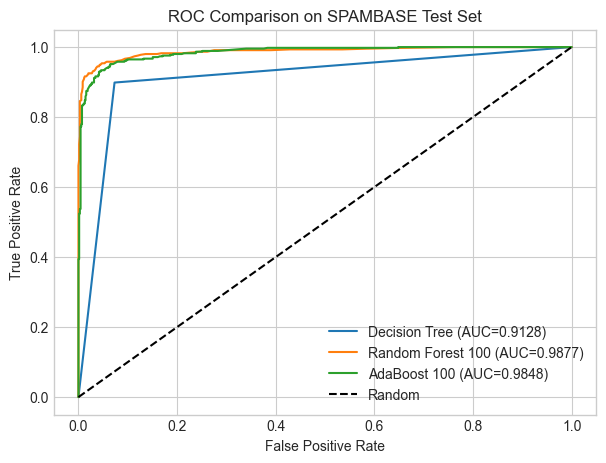

,model,auc
0,DecisionTree,0.912754
1,RandomForest_100,0.987682
2,AdaBoost_100,0.984815


In [21]:
# Problem 3.3: ROC curves for DT, RF(100), Ada(100)

# Refit chosen models for ROC
model_dt = DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE)
model_rf100 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
model_ada100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=100,
    random_state=RANDOM_STATE,
)

model_dt.fit(X_train_spam, y_train_spam)
model_rf100.fit(X_train_spam, y_train_spam)
model_ada100.fit(X_train_spam, y_train_spam)

score_dt = model_dt.predict_proba(X_test_spam)[:, 1]
score_rf = model_rf100.predict_proba(X_test_spam)[:, 1]
score_ada = model_ada100.predict_proba(X_test_spam)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test_spam, score_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test_spam, score_rf)
fpr_ada, tpr_ada, _ = roc_curve(y_test_spam, score_ada)

auc_dt = roc_auc_score(y_test_spam, score_dt)
auc_rf = roc_auc_score(y_test_spam, score_rf)
auc_ada = roc_auc_score(y_test_spam, score_ada)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest 100 (AUC={auc_rf:.4f})")
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost 100 (AUC={auc_ada:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison on SPAMBASE Test Set")
plt.legend(loc="lower right")
plt.show()

pd.DataFrame({
    "model": ["DecisionTree", "RandomForest_100", "AdaBoost_100"],
    "auc": [auc_dt, auc_rf, auc_ada],
})

### 3.1 AdaBoost with Different Numbers of Base Learners
AdaBoost improves steadily as `T` increases on this split: test accuracy goes from `0.9105` (T=10) to `0.9461` (T=500), F1 from `0.8844` to `0.9314`, and AUC from `0.9669` to `0.9866`. This is consistent with boosting progressively reducing bias by focusing on hard examples.

### 3.2 AdaBoost vs Random Forest
For all tested `T`, Random Forest is slightly better than AdaBoost on test metrics in this run (for example at `T=100`: RF accuracy `0.9566` vs Ada `0.9444`; RF F1 `0.9438` vs Ada `0.9289`; RF AUC `0.9877` vs Ada `0.9848`). AdaBoost remains competitive, but RF is the stronger overall choice here.

### 3.3 ROC Curve Comparison
The ROC/AUC comparison shows both ensembles strongly outperform a single tree: DT AUC is about `0.9128`, RF(100) is about `0.9877`, and AdaBoost(100) is about `0.9848`. RF(100) has the best discrimination overall on the SPAMBASE test set.

In [22]:
# Problem 4: Load Mushroom dataset (local-first, then URL fallback)

MUSHROOM_LOCAL = "mushroom/agaricus-lepiota.data"
MUSHROOM_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"

if os.path.exists(MUSHROOM_LOCAL):
    mush_df = pd.read_csv(MUSHROOM_LOCAL, header=None)
else:
    mush_df = pd.read_csv(MUSHROOM_URL, header=None)

print("Mushroom shape:", mush_df.shape)
mush_df.head()

Mushroom shape: (8124, 23)


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [23]:
# Problem 4.1 and 4.2: Encode, split, and implement custom Naive Bayes with Laplace smoothing

# Class label is first column: e (edible), p (poisonous)
y_raw = mush_df.iloc[:, 0].values
X_raw = mush_df.iloc[:, 1:].copy()

# Encode each categorical feature
feature_encoders = {}
X_enc = pd.DataFrame()
for col in X_raw.columns:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_raw[col].astype(str))
    feature_encoders[col] = le

# Encode class so that poisonous=1, edible=0
y = np.where(y_raw == "p", 1, 0)
X = X_enc.values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)


class CustomCategoricalNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.class_count_ = {}
        self.class_log_prior_ = {}
        self.feature_log_prob_ = {}
        self.feature_cardinality_ = []

        for j in range(n_features):
            self.feature_cardinality_.append(int(np.max(X[:, j])) + 1)

        for c in self.classes_:
            idx = (y == c)
            Xc = X[idx]
            Nc = Xc.shape[0]
            self.class_count_[c] = Nc
            self.class_log_prior_[c] = np.log(Nc / n_samples)

            self.feature_log_prob_[c] = {}
            for j in range(n_features):
                Kj = self.feature_cardinality_[j]
                counts = np.bincount(Xc[:, j], minlength=Kj)
                probs = (counts + self.alpha) / (Nc + self.alpha * Kj)
                self.feature_log_prob_[c][j] = np.log(probs)

        return self

    def predict_log_proba(self, X):
        X = np.asarray(X)
        n_samples, n_features = X.shape
        out = np.zeros((n_samples, len(self.classes_)))

        for i in range(n_samples):
            for ci, c in enumerate(self.classes_):
                lp = self.class_log_prior_[c]
                for j in range(n_features):
                    xij = X[i, j]
                    lp += self.feature_log_prob_[c][j][xij]
                out[i, ci] = lp

        # Normalize log-probs
        max_log = np.max(out, axis=1, keepdims=True)
        stabilized = out - max_log
        probs = np.exp(stabilized)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return np.log(probs)

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


custom_nb = CustomCategoricalNB(alpha=1.0)
custom_nb.fit(X_train_m, y_train_m)

custom_prior_df = pd.DataFrame({
    "class": ["edible(0)", "poisonous(1)"],
    "prior": [
        np.exp(custom_nb.class_log_prior_[0]),
        np.exp(custom_nb.class_log_prior_[1]),
    ],
})

print("Estimated class priors:")
display(custom_prior_df)

# Show sample conditional probabilities for first 3 features and both classes
sample_rows = []
for c in custom_nb.classes_:
    for j in range(min(3, X_train_m.shape[1])):
        probs = np.exp(custom_nb.feature_log_prob_[c][j])
        sample_rows.append({
            "class": int(c),
            "feature_index": j,
            "num_categories": len(probs),
            "first_5_probs": probs[:5],
        })

sample_conditional_df = pd.DataFrame(sample_rows)
print("Sample conditional probability tables (truncated):")
display(sample_conditional_df)

Estimated class priors:


,class,prior
0,edible(0),0.517971
1,poisonous(1),0.482029


Sample conditional probability tables (truncated):


,class,feature_index,num_categories,first_5_probs
0,0,0,6,"[0.09582542694497154, 0.00031625553447185337, ..."
1,0,1,4,"[0.37373417721518987, 0.00031645569620253154, ..."
2,0,2,10,"[0.011054958938723942, 0.008843967150979154, 0..."
3,1,0,6,"[0.014271151885830783, 0.0013591573224600753, ..."
4,1,1,4,"[0.19007140428425706, 0.0013600816048962934, 0..."
5,1,2,10,"[0.03189684424838819, 0.004071937563624024, 0...."


In [24]:
# Problem 4.3 and 4.4: Evaluate custom NB and compare to sklearn CategoricalNB

# Custom NB predictions
custom_proba = custom_nb.predict_proba(X_test_m)[:, 1]  # probability of poisonous (class 1)
custom_pred = custom_nb.predict(X_test_m)

custom_metrics = {
    "accuracy": accuracy_score(y_test_m, custom_pred),
    "precision": precision_score(y_test_m, custom_pred, zero_division=0),
    "recall": recall_score(y_test_m, custom_pred, zero_division=0),
    "f1": f1_score(y_test_m, custom_pred, zero_division=0),
}

# sklearn CategoricalNB
sk_nb = CategoricalNB(alpha=1.0)
sk_nb.fit(X_train_m, y_train_m)
sk_pred = sk_nb.predict(X_test_m)
sk_proba = sk_nb.predict_proba(X_test_m)[:, 1]

sk_metrics = {
    "accuracy": accuracy_score(y_test_m, sk_pred),
    "precision": precision_score(y_test_m, sk_pred, zero_division=0),
    "recall": recall_score(y_test_m, sk_pred, zero_division=0),
    "f1": f1_score(y_test_m, sk_pred, zero_division=0),
}

nb_compare_df = pd.DataFrame([
    {"model": "CustomNaiveBayes", **custom_metrics},
    {"model": "SklearnCategoricalNB", **sk_metrics},
])

print("Naive Bayes comparison on Mushroom test set")
display(nb_compare_df)

# Show sample posterior probabilities for first 10 test rows
sample_post = pd.DataFrame({
    "true_label": y_test_m[:10],
    "custom_prob_poisonous": custom_proba[:10],
    "sklearn_prob_poisonous": sk_proba[:10],
    "custom_pred": custom_pred[:10],
    "sklearn_pred": sk_pred[:10],
})

print("Sample posterior probabilities (first 10 test rows)")
display(sample_post)

Naive Bayes comparison on Mushroom test set


,model,accuracy,precision,recall,f1
0,CustomNaiveBayes,0.94387,0.995418,0.88764,0.938445
1,SklearnCategoricalNB,0.94387,0.995418,0.88764,0.938445


Sample posterior probabilities (first 10 test rows)


,true_label,custom_prob_poisonous,sklearn_prob_poisonous,custom_pred,sklearn_pred
0,0,4.200284e-05,4.200284e-05,0,0
1,0,6.640377e-11,6.640377e-11,0,0
2,1,1.000000e+00,1.000000e+00,1,1
3,0,3.499486e-13,3.499486e-13,0,0
4,0,5.892334e-09,5.892334e-09,0,0
5,1,1.000000e+00,1.000000e+00,1,1
6,0,1.135250e-12,1.135250e-12,0,0
7,1,1.000000e+00,1.000000e+00,1,1
8,1,1.000000e+00,1.000000e+00,1,1
9,0,1.476962e-06,1.476962e-06,0,0


### 4.1 Priors and Conditional Probabilities with Laplace Smoothing
The estimated class priors from training data are approximately `P(Edible)=0.5180` and `P(Poisonous)=0.4820`. Conditional probabilities are computed per feature/category/class with Laplace smoothing (`alpha=1`), ensuring no category gets zero probability even if unseen in a class.

### 4.2 Posterior Estimation for Test Points
For each test mushroom, the classifier computes log-posteriors for edible vs poisonous by adding log prior and log conditional probabilities across all 22 attributes. The sample posterior table confirms sensible outputs: many poisonous examples have predicted probability near 1 for class 1, while edible examples have near 0.

### 4.3 Custom Naive Bayes Metrics
On the test set, the custom model achieves accuracy `0.9439`, precision `0.9954`, recall `0.8876`, and F1 `0.9384`. This is strong performance and indicates very low false positives (high precision) with somewhat lower recall.

### 4.4 Custom vs Package Naive Bayes
The custom implementation and `SklearnCategoricalNB` produce identical metrics on this split (all four metrics match to the displayed precision), which validates the correctness of the custom Laplace-smoothed Naive Bayes implementation.